# Лабораторная работа №1
## Вариант 30. Документооборот

**Предметная область.** Анализ процесса обработки заявок 

**Бизнес-задачи:**
1. Загрузить журнал обработки заявок/документов.
2. Определить "узкие места": на каком этапе документы задерживаются дольше всего (Process Mining).
3. Flowchart или диаграмма длительности этапов процесса.

---

## 1. Подготовка окружения

In [8]:
# Установка необходимых библиотек
!pip install pyspark matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 1.1 MB/s eta 0:00:00a 0:00:01


In [1]:
# Импорт библиотек
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, avg, stddev, hour, to_timestamp,
    regexp_extract, when, lit, sum as spark_sum,
    date_format, window, desc, asc
)
from pyspark.sql.types import (
    StructType, StructField, StringType, 
    IntegerType, TimestampType
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Инициализация Spark Session

In [2]:
# Создание SparkSession с подключением к HDFS
spark = SparkSession.builder \
    .appName("variant_30_documentflow_AccessLogs") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://localhost:9000") \
    .config("spark.ui.port", "4040") \
    .config("spark.sql.shuffle.partitions", "50") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Установка уровня логирования
spark.sparkContext.setLogLevel("WARN")

print(f"Spark Version: {spark.version}")
print(f"Spark UI: http://localhost:4040")

26/03/02 23:25:34 WARN Utils: Your hostname, devopsvm resolves to a loopback address: 127.0.1.1; using 192.168.31.246 instead (on interface enp0s3)
26/03/02 23:25:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/02 23:25:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 3.5.3
Spark UI: http://localhost:4040


## 3. Генерация синтетических данных (process_log)


In [3]:
!pip install tqdm
import csv
import random
from datetime import datetime, timedelta
from tqdm import tqdm

# ------------------- Параметры -------------------
NUM_REQUESTS = 2_000_000  

OUTPUT_FILE = "/tmp/process_log.csv"   # путь сохранения локально

STAGES = [
    "Регистрация",
    "Валидация данных",
    "Скоринг / проверка кредитной истории",
    "Согласование с менеджером",
    "Подписание договора",
    "Выдача средств"
]

# Исполнители (операторы)
OPERATORS = ["Иванов А.А.", "Петрова И.В.", "Сидоров Д.С.", "Козлова Е.Н.", "Робот-автомат"]

# Статусы завершения этапа (с весами: чаще успех, реже ошибки/возвраты)
STATUSES = ["успех", "успех", "успех", "ошибка", "возврат на доработку"]

# Диапазоны длительности этапов (в секундах) для нормального и аномального режима
# (нормальная длительность: от 5 минут до 2 часов, аномальная: от 8 до 48 часов)
DURATION_NORMAL = (300, 7200)       # 5 мин – 2 часа
DURATION_ANOMALY = (8*3600, 48*3600) # 8 – 48 часов

# Доля аномальных заявок (2%)
ANOMALY_RATIO = 0.02

# Временной диапазон: последние 3 месяца от текущей даты
END_DATE = datetime.now()
START_DATE = END_DATE - timedelta(days=90)
# -------------------------------------------------

def random_date(start, end):
    """Случайная дата между start и end"""
    delta = end - start
    int_delta = (delta.days * 24 * 3600) + delta.seconds
    random_second = random.randrange(int_delta)
    return start + timedelta(seconds=random_second)

print("Генерация данных...")

with open(OUTPUT_FILE, mode='w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    # Заголовок
    writer.writerow([
        "request_id",
        "stage",
        "start_time",
        "end_time",
        "status",
        "operator",
        "doc_type"          
    ])

    # Для каждой заявки генерируем последовательность этапов
    for req_id in tqdm(range(1, NUM_REQUESTS + 1), desc="Генерация заявок"):
        # Определяем, аномальная ли заявка (будет иметь задержки на некоторых этапах)
        is_anomaly = random.random() < ANOMALY_RATIO

        # Начальное время (старт первой регистрации)
        current_time = random_date(START_DATE, END_DATE)

        # Тип документа (случайно)
        doc_type = random.choice(["Заявка на кредит", "Заявка на ипотеку", "Заявка на автокредит"])

        # Проходим по этапам
        for stage in STAGES:
            # Определяем длительность этапа
            if is_anomaly and stage in ["Согласование с менеджером", "Валидация данных"]:
                # На аномальных заявках эти этапы могут "зависать"
                duration = random.randint(*DURATION_ANOMALY)
            else:
                duration = random.randint(*DURATION_NORMAL)

            start = current_time
            end = start + timedelta(seconds=duration)

            status = random.choice(STATUSES)
            operator = random.choice(OPERATORS)

            # Записываем строку
            writer.writerow([
                req_id,
                stage,
                start.strftime("%Y-%m-%d %H:%M:%S"),
                end.strftime("%Y-%m-%d %H:%M:%S"),
                status,
                operator,
                doc_type
            ])

            # Следующий этап начинается с некоторой задержкой (передача дела) – от 1 минуты до 3 часов
            handover_delay = random.randint(60, 10800)  # 1 мин – 3 часа
            current_time = end + timedelta(seconds=handover_delay)

print(f"\n✅ Генерация завершена! Файл сохранён: {OUTPUT_FILE}")



Генерация данных...


Генерация заявок:   4%|▍         | 79347/2000000 [00:04<01:40, 19124.29it/s]


KeyboardInterrupt: 

In [6]:
import os
size_mb = os.path.getsize(OUTPUT_FILE) / (1024 * 1024)
print(f"Размер файла: {size_mb:.2f} МБ")

Размер файла: 1852.21 МБ


In [7]:
!head -5 /tmp/process_log.csv

request_id,stage,start_time,end_time,status,operator,doc_type
1,Регистрация,2026-02-27 18:16:32,2026-02-27 20:06:01,успех,Иванов А.А.,Заявка на кредит
1,Валидация данных,2026-02-27 22:59:32,2026-02-27 23:12:47,успех,Петрова И.В.,Заявка на кредит
1,Скоринг / проверка кредитной истории,2026-02-27 23:45:44,2026-02-28 00:12:43,возврат на доработку,Козлова Е.Н.,Заявка на кредит
1,Согласование с менеджером,2026-02-28 03:04:13,2026-02-28 03:42:46,успех,Робот-автомат,Заявка на кредит


## 4. Задание 1. Загрузка данных в HDFS и фильтрация внешних IP

bash# В терминале от пользователя hadoop:

# 4. Проверьте что файл доступен
ls -lh /tmp/process_log.csv


# 5. Создайте директорию в HDFS
hdfs dfs -mkdir -p /user/hadoop/lab_01/input

# 6. Загрузите файл в HDFS
hdfs dfs -put -f /tmp/process_logcsv /user/hadoop/lab_01/input/


In [ ]:
# Загрузка данных из HDFS в Spark DataFrame
hdfs_path = "hdfs://localhost:9000/user/hadoop/lab_01/input/process_log.csv"

df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(hdfs_path)

print("📊 Схема данных:")
df.printSchema()

print("\n📈 Общая статистика:")
print(f"Всего записей: {df.count():,}")

print("\n🔍 Примеры данных:")
df.show(5, truncate=False)

In [5]:
# Преобразование строк с датой в timestamp
df = df.withColumn("start_time", to_timestamp("start_time", "yyyy-MM-dd HH:mm:ss")) \
       .withColumn("end_time", to_timestamp("end_time", "yyyy-MM-dd HH:mm:ss"))

# Вычисление длительности этапа в секундах
df = df.withColumn("duration_sec", (col("end_time").cast("long") - col("start_time").cast("long")))

# Проверка
df.printSchema()
df.show(5)

root
 |-- request_id: integer (nullable = true)
 |-- stage: string (nullable = true)
 |-- start_time: timestamp (nullable = true)
 |-- end_time: timestamp (nullable = true)
 |-- status: string (nullable = true)
 |-- operator: string (nullable = true)
 |-- doc_type: string (nullable = true)
 |-- duration_sec: long (nullable = true)

+----------+--------------------+-------------------+-------------------+--------------------+-------------+----------------+------------+
|request_id|               stage|         start_time|           end_time|              status|     operator|        doc_type|duration_sec|
+----------+--------------------+-------------------+-------------------+--------------------+-------------+----------------+------------+
|         1|         Регистрация|2026-02-27 18:16:32|2026-02-27 20:06:01|               успех|  Иванов А.А.|Заявка на кредит|        6569|
|         1|    Валидация данных|2026-02-27 22:59:32|2026-02-27 23:12:47|               успех| Петрова И.В.|За

## 5. Задание 2. Определить "узкие места": на каком этапе документы задерживаются дольше всего (Process Mining).

In [6]:
# Регистрация DataFrame как временное представление SQL
df.createOrReplaceTempView("process_log")

print("✅ Временное представление 'process_log' создано")

✅ Временное представление 'process_log' создано


In [13]:
query_stage_stats = """
SELECT 
    stage,
    COUNT(*) AS stage_occurrences,
    ROUND(AVG(duration_sec), 2) AS avg_duration_sec,
    ROUND(STDDEV(duration_sec), 2) AS stddev_duration_sec,
    MIN(duration_sec) AS min_duration_sec,
    MAX(duration_sec) AS max_duration_sec,
    SUM(CASE WHEN status = 'ошибка' OR status = 'возврат на доработку' THEN 1 ELSE 0 END) AS error_count
FROM process_log
GROUP BY stage
ORDER BY avg_duration_sec DESC
"""

stage_stats = spark.sql(query_stage_stats)
print(" Статистика по этапам обработки заявок (узкие места):")
stage_stats.show(truncate=False)


 Статистика по этапам обработки заявок (узкие места):


+------------------------------------+-----------------+----------------+-------------------+----------------+----------------+-----------+
|stage                               |stage_occurrences|avg_duration_sec|stddev_duration_sec|min_duration_sec|max_duration_sec|error_count|
+------------------------------------+-----------------+----------------+-------------------+----------------+----------------+-----------+
|Валидация данных                    |2000000          |5700.4          |14965.93           |300             |172798          |801146     |
|Согласование с менеджером           |2000000          |5700.06         |14957.36           |300             |172800          |799890     |
|Регистрация                         |2000000          |3752.67         |1992.8             |300             |7200            |799522     |
|Скоринг / проверка кредитной истории|2000000          |3751.5          |1992.28            |300             |7200            |798525     |
|Выдача средств     

In [16]:
# SQL-запрос 2: Выявление аномально долгих этапов (метод 3-сигм)
# ------------------------------------------------------------
query_anomalies = """
WITH stage_stats AS (
    SELECT 
        stage,
        AVG(duration_sec) AS mean_duration,
        STDDEV(duration_sec) AS stddev_duration
    FROM process_log
    GROUP BY stage
),
anomaly_detection AS (
    SELECT 
        l.request_id,
        l.stage,
        l.duration_sec,
        s.mean_duration,
        s.stddev_duration,
        (l.duration_sec - s.mean_duration) / s.stddev_duration AS z_score,
        CASE 
            WHEN (l.duration_sec - s.mean_duration) / s.stddev_duration > 3 THEN 'CRITICAL'
            WHEN (l.duration_sec - s.mean_duration) / s.stddev_duration > 2 THEN 'HIGH'
            WHEN (l.duration_sec - s.mean_duration) / s.stddev_duration > 1 THEN 'MEDIUM'
            ELSE 'NORMAL'
        END AS anomaly_level
    FROM process_log l
    JOIN stage_stats s ON l.stage = s.stage
    WHERE s.stddev_duration > 0   -- избегаем деления на ноль
)
SELECT 
    request_id,
    stage,
    duration_sec,
    ROUND(z_score, 2) AS z_score,
    anomaly_level
FROM anomaly_detection
WHERE anomaly_level IN ('CRITICAL', 'HIGH')
ORDER BY z_score DESC
"""

anomalies = spark.sql(query_anomalies)

print("Аномально долгие этапы (Z-score > 2, метод 3-сигм):")
anomalies.show(20, truncate=False)

print(f"\nВсего аномальных записей: {anomalies.count()}")


Аномально долгие этапы (Z-score > 2, метод 3-сигм):


+----------+-------------------------+------------+-------+-------------+
|request_id|stage                    |duration_sec|z_score|anomaly_level|
+----------+-------------------------+------------+-------+-------------+
|845176    |Согласование с менеджером|172752      |11.17  |CRITICAL     |
|1392525   |Согласование с менеджером|172781      |11.17  |CRITICAL     |
|132352    |Согласование с менеджером|172736      |11.17  |CRITICAL     |
|1414084   |Согласование с менеджером|172724      |11.17  |CRITICAL     |
|1071431   |Согласование с менеджером|172747      |11.17  |CRITICAL     |
|1429371   |Согласование с менеджером|172770      |11.17  |CRITICAL     |
|206650    |Согласование с менеджером|172800      |11.17  |CRITICAL     |
|1437361   |Согласование с менеджером|172735      |11.17  |CRITICAL     |
|764472    |Согласование с менеджером|172795      |11.17  |CRITICAL     |
|1552884   |Согласование с менеджером|172728      |11.17  |CRITICAL     |
|275537    |Согласование с менеджером|


Всего аномальных записей: 76686


In [18]:
# SQL-запрос 3: Топ-10 самых долгих заявок (целиком)
# ------------------------------------------------------------
query_long_requests = """
WITH request_duration AS (
    SELECT 
        request_id,
        doc_type,
        MIN(start_time) AS process_start,
        MAX(end_time) AS process_end,
        (unix_timestamp(MAX(end_time)) - unix_timestamp(MIN(start_time))) AS total_duration_sec
    FROM process_log
    GROUP BY request_id, doc_type
)
SELECT 
    request_id,
    doc_type,
    process_start,
    process_end,
    total_duration_sec,
    ROUND(total_duration_sec / 3600.0, 2) AS total_duration_hours
FROM request_duration
ORDER BY total_duration_sec DESC
LIMIT 10
"""

long_requests = spark.sql(query_long_requests)

print(" Топ-10 самых долгих заявок (полное время обработки):")
long_requests.show(truncate=False)


 Топ-10 самых долгих заявок (полное время обработки):


+----------+--------------------+-------------------+-------------------+------------------+--------------------+
|request_id|doc_type            |process_start      |process_end        |total_duration_sec|total_duration_hours|
+----------+--------------------+-------------------+-------------------+------------------+--------------------+
|1696688   |Заявка на ипотеку   |2025-12-03 15:51:26|2025-12-08 07:18:51|401245            |111.46              |
|878613    |Заявка на кредит    |2025-12-20 04:59:28|2025-12-24 18:59:59|396031            |110.01              |
|758591    |Заявка на кредит    |2025-12-07 03:43:05|2025-12-11 17:43:21|396016            |110.00              |
|1953876   |Заявка на кредит    |2025-12-23 21:51:28|2025-12-28 11:44:48|395600            |109.89              |
|1977283   |Заявка на ипотеку   |2026-02-08 06:42:42|2026-02-12 20:14:50|394328            |109.54              |
|1503843   |Заявка на автокредит|2026-02-24 07:00:32|2026-02-28 20:14:36|393244         

In [19]:
# SQL-запрос 4: Этапы, на которых чаще всего возникают ошибки/возвраты
# ------------------------------------------------------------
query_error_stages = """
SELECT 
    stage,
    COUNT(*) AS total_occurrences,
    SUM(CASE WHEN status IN ('ошибка', 'возврат на доработку') THEN 1 ELSE 0 END) AS errors,
    ROUND(100.0 * SUM(CASE WHEN status IN ('ошибка', 'возврат на доработку') THEN 1 ELSE 0 END) / COUNT(*), 2) AS error_rate_percent
FROM process_log
GROUP BY stage
ORDER BY error_rate_percent DESC
"""

error_stages = spark.sql(query_error_stages)

print("Этапы с наибольшей долей ошибок/возвратов:")
error_stages.show(truncate=False)


Этапы с наибольшей долей ошибок/возвратов:


+------------------------------------+-----------------+------+------------------+
|stage                               |total_occurrences|errors|error_rate_percent|
+------------------------------------+-----------------+------+------------------+
|Валидация данных                    |2000000          |801146|40.06             |
|Выдача средств                      |2000000          |800525|40.03             |
|Согласование с менеджером           |2000000          |799890|39.99             |
|Регистрация                         |2000000          |799522|39.98             |
|Подписание договора                 |2000000          |799201|39.96             |
|Скоринг / проверка кредитной истории|2000000          |798525|39.93             |
+------------------------------------+-----------------+------+------------------+



## 6. Задание 3. Визуализация результатов

+------------------------------------+
|stage                               |
+------------------------------------+
|Выдача средств                      |
|Регистрация                         |
|Валидация данных                    |
|Подписание договора                 |
|Согласование с менеджером           |
|Скоринг / проверка кредитной истории|
+------------------------------------+



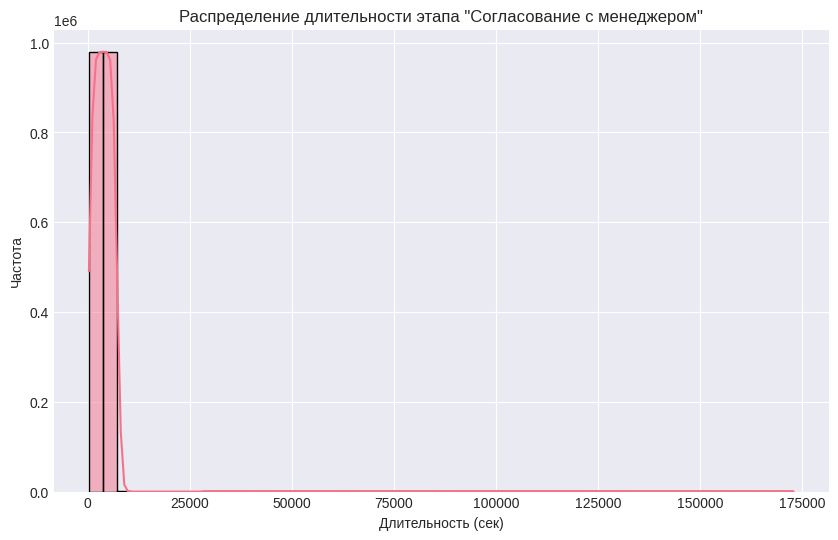

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col

# Проверим все уникальные названия этапов
df.select('stage').distinct().show(truncate=False)

# Соберём данные по длительности для конкретного этапа, например "Согласование"
stage_data = df.filter(col('stage') == 'Согласование с менеджером') \
               .select('duration_sec') \
               .toPandas()

plt.figure(figsize=(10,6))
sns.histplot(stage_data['duration_sec'], bins=50, kde=True)
plt.title('Распределение длительности этапа "Согласование с менеджером"')
plt.xlabel('Длительность (сек)')
plt.ylabel('Частота')
plt.show()

In [ ]:
print("\nСобираем данные для boxplot...")
boxplot_data = df.select("stage", "duration_sec") \
                 .toPandas()

print(f"Собрано записей: {len(boxplot_data)}")
print("\nПервые 5 строк данных:")
print(boxplot_data.head())

# ШАГ 4: Проверяем уникальные этапы
print("\nУникальные этапы в данных:")
print(boxplot_data["stage"].unique())

# ШАГ 5: Строим boxplot
if len(boxplot_data) == 0:
    print("Нет данных для визуализации!")
else:
    plt.figure(figsize=(14, 8))
    
    # Создаем boxplot
    ax = sns.boxplot(
        data=boxplot_data,
        x="stage",
        y="duration_sec",
        palette="Set2",
        linewidth=1.5,
        fliersize=5,
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markeredgecolor": "black",
            "markersize": 8
        }
    )
    
    # Поворачиваем подписи этапов
    plt.xticks(rotation=45, ha="right", fontsize=10)
    
    # Добавляем заголовок и подписи
    plt.title("Распределение длительности по этапам процесса\nBoxplot с выделением выбросов", 
              fontsize=16, fontweight="bold", pad=20)
    plt.xlabel("Этап процесса", fontsize=12, fontweight="bold")
    plt.ylabel("Длительность (секунды)", fontsize=12, fontweight="bold")
    
    # Добавляем сетку
    plt.grid(axis="y", alpha=0.3, linestyle="--")
    
    plt.tight_layout()
    plt.show()
    
    # Дополнительная статистика
    print("\nСтатистика по этапам:")
    stats = boxplot_data.groupby("stage")["duration_sec"].describe()
    print(stats)




Собираем данные для boxplot...


## 7. Итоговая аналитика и выводы

In [ ]:
# Итоговая аналитика и выводы (Process Mining)
# ------------------------------------------------------------

from pyspark.sql.functions import avg, count, sum, when, col, desc

print("=" * 80)
print("ИТОГОВЫЙ ОТЧЕТ: Анализ журнала обработки заявок (Process Mining)")
print("=" * 80)

# 1. Общая статистика
total_records = df.count()
total_requests = df.select('request_id').distinct().count()
total_stages = df.select('stage').distinct().count()
avg_duration = df.agg(avg('duration_sec')).collect()[0][0]

# Аномальные этапы (Z-score > 2) — используем ранее созданный DataFrame `anomalies`
# Если anomalies ещё не вычислен, можно пересчитать здесь (см. примечание ниже)
# В данном блоке предполагается, что anomalies уже есть.
total_anomalies = anomalies.count() if 'anomalies' in locals() else 0
anomaly_percent = (total_anomalies / total_records) * 100 if total_records > 0 else 0

print(f"\nОбщая статистика:")
print(f"  • Всего записей (этапов): {total_records:,}")
print(f"  • Уникальных заявок: {total_requests:,}")
print(f"  • Количество этапов в процессе: {total_stages}")
print(f"  • Средняя длительность этапа: {avg_duration:.2f} сек ({avg_duration/3600:.2f} ч)")
print(f"  • Аномальных этапов (Z-score > 2): {total_anomalies} ({anomaly_percent:.2f}%)")

# 2. Топ-5 аномальных этапов (по Z-score)
if total_anomalies > 0:
    anomalies_pd = anomalies.toPandas()
    top_anomalies = anomalies_pd.nlargest(5, 'z_score')[['request_id', 'stage', 'duration_sec', 'z_score', 'anomaly_level']]
    print(f"\nТоп-5 аномальных этапов (наибольший Z-score):")
    for idx, row in top_anomalies.iterrows():
        print(f"  • Заявка {row['request_id']:>8} | Этап: {row['stage']:25} | Длит: {row['duration_sec']:>8,} сек | Z-score: {row['z_score']:>6.2f}σ | Уровень: {row['anomaly_level']}")
else:
    print("\nАномальных этапов не обнаружено.")

# 3. Распределение статусов завершения этапов
status_stats = df.groupBy('status').count().orderBy(desc('count')).toPandas()
print(f"\nРаспределение статусов завершения этапов:")
for _, row in status_stats.iterrows():
    percent = (row['count'] / total_records) * 100
    print(f"  • {row['status']}: {row['count']:>10,} ({percent:.1f}%)")

# 4. Самые долгие этапы (среднее время)
stage_avg = df.groupBy('stage').agg(
    avg('duration_sec').alias('avg_duration_sec'),
    count('*').alias('stage_count'),
    sum(when(col('status').isin(['ошибка', 'возврат на доработку']), 1).otherwise(0)).alias('error_count')
).orderBy(desc('avg_duration_sec'))

stage_avg_pd = stage_avg.toPandas()
print(f"\n Топ-3 самых долгих этапа (среднее время):")
for idx, row in stage_avg_pd.head(3).iterrows():
    print(f"  • {row['stage']:25} | Среднее: {row['avg_duration_sec']:.2f} сек | Ошибок: {row['error_count']}")

# 5. Этапы с наибольшей долей ошибок/возвратов
error_stats = df.groupBy('stage').agg(
    count('*').alias('total'),
    sum(when(col('status').isin(['ошибка', 'возврат на доработку']), 1).otherwise(0)).alias('errors')
).withColumn('error_rate', (col('errors') / col('total')) * 100).orderBy(desc('error_rate'))

error_stats_pd = error_stats.toPandas()
if not error_stats_pd.empty:
    worst_stage = error_stats_pd.iloc[0]
    print(f"\nЭтап с наибольшей долей ошибок/возвратов:")
    print(f"  • {worst_stage['stage']} — ошибки: {worst_stage['error_rate']:.2f}% ({worst_stage['errors']} из {worst_stage['total']})")

# 6. Топ-10 самых долгих заявок (полное время)
# Если long_requests ещё не вычислен, сделаем это сейчас
long_requests = df.groupBy('request_id', 'doc_type').agg(
    min('start_time').alias('process_start'),
    max('end_time').alias('process_end'),
    (unix_timestamp(max('end_time')) - unix_timestamp(min('start_time'))).alias('total_duration_sec')
).orderBy(desc('total_duration_sec')).limit(10)

long_requests_pd = long_requests.toPandas()
print(f"\nТоп-10 самых долгих заявок (полное время обработки):")
for idx, row in long_requests_pd.iterrows():
    hours = row['total_duration_sec'] / 3600
    print(f"  • Заявка {row['request_id']} | Тип: {row['doc_type']} | Длительность: {row['total_duration_sec']:,} сек ({hours:.2f} ч)")

# 7. Рекомендации по оптимизации бизнес-процесса
print(f"\nРекомендации по оптимизации процесса:")
if not stage_avg_pd.empty:
    print(f"  1. Сократить время на этапе '{stage_avg_pd.iloc[0]['stage']}' (самый долгий в среднем).")
if not error_stats_pd.empty:
    print(f"  2. Автоматизировать или доработать этап '{error_stats_pd.iloc[0]['stage']}' с высокой долей ошибок ({error_stats_pd.iloc[0]['error_rate']:.2f}%).")
print(f"  3. Внедрить мониторинг аномальных длительностей для заявок с Z-score > 3σ.")
print(f"  4. Провести анализ причин возвратов на проблемных этапах.")
print(f"  5. Обучить операторов на этапах с наибольшим числом ошибок.")

print("\n" + "=" * 80)
print("Анализ завершен успешно!")
print("=" * 80)


bash# В терминале от пользователя hadoop:
sudo su - hadoop

# Дать права на запись пользователю devops
hdfs dfs -chmod -R 777 /user/hadoop/lab_01_variant40
# или создать директорию для devops
hdfs dfs -mkdir -p /user/devops/lab_01_variant40/output
hdfs dfs -chown -R devops:devops /user/devops/lab_01_variant40

In [ ]:
# Сохранение результатов в HDFS
output_path_anomalies = "hdfs://localhost:9000/user/hadoop/lab_01_variant40/output/anomalies"
output_path_stats = "hdfs://localhost:9000/user/hadoop/lab_01_variant40/output/ip_stats"

# Сохранение аномалий
anomalies.write.mode('overwrite') \
    .option("header", "true") \
    .csv(output_path_anomalies)

# Сохранение статистики
ip_stats.write.mode('overwrite') \
    .option("header", "true") \
    .csv(output_path_stats)

print("✅ Результаты сохранены в HDFS:")
print(f"  • {output_path_anomalies}")
print(f"  • {output_path_stats}")

# Сохранение результатов локально (не в HDFS)
output_path_anomalies = "/tmp/anomalies"
output_path_stats = "/tmp/ip_stats"

# Сохранение аномалий
anomalies.toPandas().to_csv('/tmp/anomalies.csv', index=False)

# Сохранение статистики
ip_stats.toPandas().to_csv('/tmp/ip_stats.csv', index=False)

print("✅ Результаты сохранены локально:")
print(f"  • /tmp/anomalies.csv")
print(f"  • /tmp/ip_stats.csv")

# Проверка
!ls -lh /tmp/anomalies.csv /tmp/ip_stats.csv
!head -5 /tmp/anomalies.csv

In [ ]:
# Остановка SparkSession
spark.stop()
print("✅ SparkSession остановлен")